In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-images-idx3-ubyte


In [2]:
!pip install -q -U protobuf==6.33.6 mlflow optuna-integration


In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim

import optuna


In [4]:
# Create a manual seed to reproduce your results
torch.manual_seed(42)

In [5]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
training_set = pd.read_csv("/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv")
testing_set = pd.read_csv("/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv")

In [7]:
training_set.head() # This is an image dataset apparently on fashion products and all

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# So here each pixel value of the grid was squeezed into a single row by placing the original grid rows side by side
# The label values are some sort of identity of these products.

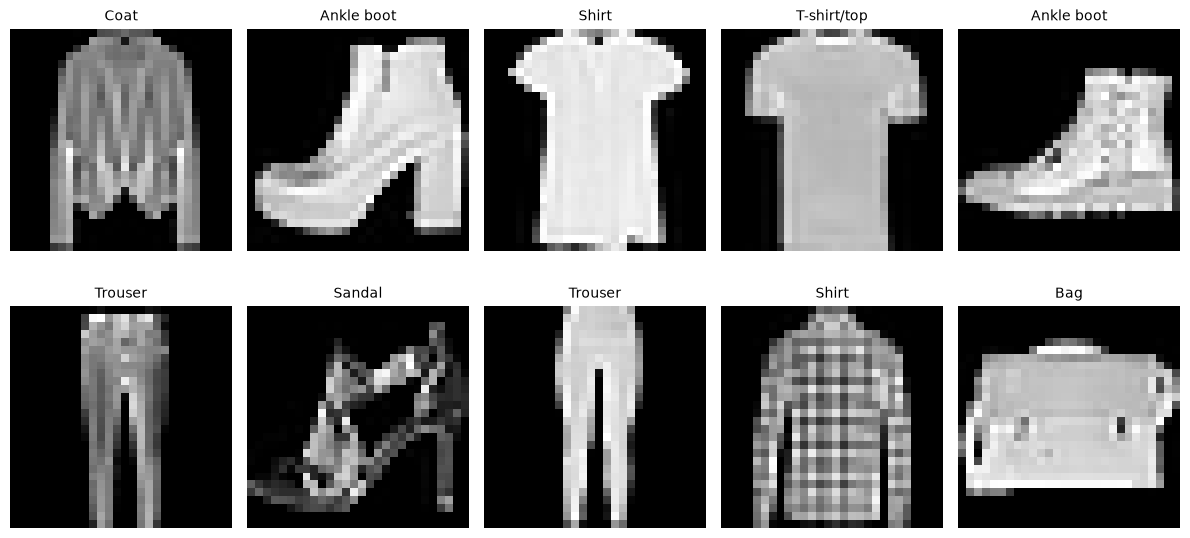

In [9]:
# Plotting the rows one by one

# 1. Define the descriptive text labels for Fashion MNIST
label_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# 2. Sample 10 random rows from your loaded DataFrame
sample_df = training_set.sample(n=10, random_state=42)

# 3. Setup a grid layout (2 rows by 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, (index, row) in enumerate(sample_df.iterrows()):
    # Get the clothing category index from the 'label' column
    label_idx = int(row["label"])

    # Drop the label to keep only the pixel values (pixel1 to pixel784)
    pixel_values = row.drop("label").values

    # Reshape the flat 784 pixels back into a 28x28 grid
    image_matrix = pixel_values.reshape(28, 28)

    # Plot the matrix using a grayscale map
    axes[i].imshow(image_matrix, cmap="gray")
    axes[i].set_title(label_names[label_idx], fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Split the data into sets

X_train = training_set.iloc[:,1:].values
y_train = training_set.iloc[:,0].values

# Now correctly using the separate testing_set loaded from the test CSV
X_test = testing_set.iloc[:,1:].values
y_test = testing_set.iloc[:,0].values

In [11]:
# Now StandardScale the features
X_train = X_train/255.0
X_test = X_test/255.0

In [12]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.00392157,
        0.        ],
       [0.        , 0.00392157, 0.01176471, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(10000, 784))

In [13]:
# Create a Dataset Class
class MyCustomDataset(Dataset):
  def __init__(self,features,labels):
     super().__init__()
     self.features = torch.tensor(features,dtype=torch.float32)
     self.labels = torch.tensor(labels,dtype=torch.long)
  def __len__(self):
    return self.features.shape[0]
  def __getitem__(self,index):
    return self.features[index],self.labels[index]

# Instantiate training and testing objects to pass on to DataLoader
training_dataset = MyCustomDataset(X_train,y_train)
testing_dataset = MyCustomDataset(X_test,y_test)

In [14]:
# Create the Neural Network
class MyANN(nn.Module):
  def __init__(self,input_cols,output_cols,n_hidden_layers,n_neurons_per_layer,dropout_rate):
     super().__init__()
     layers = []
     layers.append(nn.Flatten()) # Flatten the layer to safely pass it to BatchNorm1D
     for _ in range(n_hidden_layers):
      layers.append(nn.Linear(input_cols,n_neurons_per_layer))
      layers.append(nn.BatchNorm1d(n_neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_cols = n_neurons_per_layer
     layers.append(nn.Linear(input_cols,output_cols))

     self.network = nn.Sequential(*layers)

  def forward(self,x):
    return self.network(x)

In [15]:
# Create the objective function.

def objective(trial): # Always pass a trial to this function

  # Create trial objects for each parameter to be tuned.
  epochs = trial.suggest_int(
                              "EPOCHS", # Parameter name(for the study object)
                              10, # The lower bound
                              50, # The upper bound
                              step=10  # Step size to select values between each bounds
  )
  # Similary we can do these for other parameters as well, including : categorical,float,and other dtypes.
  n_neurons_per_layer = trial.suggest_int("N_neurons",16,128,step=8)
  n_hidden_layers = trial.suggest_int("N_layers",2,10)
  learning_rate = trial.suggest_float("LR",1e-4,1e-1,log=True)
  dropout_rate = trial.suggest_float("DR",0.1,0.5,step=0.1)
  batch_size = trial.suggest_categorical("Batch_size",[16,32,64])
  optimizer_ = trial.suggest_categorical("Optimizer",["ADAM","Adagrad","RMSProp"])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  # Create training and testing loaders (Place this code block right after we define the batch_size variable)
  train_loader = DataLoader(
      training_dataset, 
      batch_size=batch_size, 
      shuffle=True, 
      pin_memory=True, 
      num_workers=4,        # <--- THE SPEED FIX
      drop_last=True
  )
  
  test_loader = DataLoader(
      testing_dataset, 
      batch_size=batch_size, 
      shuffle=False, 
      pin_memory=True, 
      num_workers=4
  )

  # TRAINING CODE BLOCK :

  # Default Parameters :
  input_cols = 784
  output_cols = 10

  # Instantiate the model
  model = MyANN(input_cols,output_cols,n_hidden_layers,n_neurons_per_layer,dropout_rate)
  model = model.to(device)

  # loss function
  criterion = nn.CrossEntropyLoss()

  # Use conditions for choosing optimizers as we now have added a parameter to choose from .
  if optimizer_ == "ADAM":
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_ == "Adagrad":
    optimizer = optim.Adagrad(model.parameters(),lr=learning_rate, weight_decay=weight_decay)
  else:
    optimizer = optim.RMSprop(model.parameters(),lr=learning_rate, weight_decay=weight_decay)

  # Model Training

  for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_X,batch_y in train_loader:

      # Reassign variables by moving them to gpu :
      batch_X,batch_y = batch_X.to(device),batch_y.to(device)

      # Forward pass the first batch of X and get the outputs
      y_pred = model(batch_X)

      # Calculate the loss value
      loss = criterion(y_pred, batch_y) # This captures the loss itself and we do not need sigmoid here as the values are to be expected in float

      # Backward Pass the loss
      optimizer.zero_grad() # Clear gradients to avoid passsing loss of previous batch
      loss.backward()

      # Update the parameters
      optimizer.step()

      # Epoch loss for this batch (Keeps on adding all batch loss across epoch)
      total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    if (epoch+1) % 10 == 0:
      print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

  model.eval()  # Evaluate the model


  # Make predictions on testing batch .

  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

  accuracy = correct / total
  print(f"Trial Accuracy: {accuracy:.4f}")
  return accuracy  #  This passes the score back to Optuna



In [18]:
import optuna

# 1. This creates a local database file in Kaggle that auto-saves your trials instantly
study_name = "my_ann_optimization"
storage_name = f"sqlite:///{study_name}.db"

# 2. Create the study pointing to that database file
study = optuna.create_study(
    study_name=study_name, 
    storage=storage_name, 
    direction="maximize",
    load_if_exists=True # If it disconnects, running this cell again RESUMES where it left off!
)

# 3. Run your optimization smoothly without any callbacks
study.optimize(objective, n_trials=10)


[I 2026-08-09 01:31:03,335] A new study created in RDB with name: my_ann_optimization


Epoch: 10 , Loss: 0.5072714667289685
Epoch: 20 , Loss: 0.44023345234111333
Epoch: 30 , Loss: 0.42183616241583455


[I 2026-08-09 01:31:52,944] Trial 0 finished with value: 0.9069 and parameters: {'EPOCHS': 30, 'N_neurons': 56, 'N_layers': 3, 'LR': 0.0017187583841004302, 'DR': 0.30000000000000004, 'Batch_size': 32, 'Optimizer': 'ADAM', 'weight_decay': 2.7713496099083797e-05}. Best is trial 0 with value: 0.9069.


Trial Accuracy: 0.9069
Epoch: 10 , Loss: 0.6176402825766649
Epoch: 20 , Loss: 0.5389342919374124
Epoch: 30 , Loss: 0.4571314330857534
Epoch: 40 , Loss: 0.41201601425806683
Epoch: 50 , Loss: 0.38756727212323594


[I 2026-08-09 01:33:20,468] Trial 1 finished with value: 0.918 and parameters: {'EPOCHS': 50, 'N_neurons': 128, 'N_layers': 4, 'LR': 0.00010230151288651457, 'DR': 0.4, 'Batch_size': 32, 'Optimizer': 'RMSProp', 'weight_decay': 5.889101967756276e-05}. Best is trial 1 with value: 0.918.


...

Trial Accuracy: 0.8983
Epoch: 10 , Loss: 0.6017925288432684
Epoch: 20 , Loss: 0.5186173514677928
Epoch: 30 , Loss: 0.4949281963591392
Epoch: 40 , Loss: 0.4750946935934898
Epoch: 50 , Loss: 0.4584054155036425


[I 2026-08-09 01:41:13,541] Trial 8 finished with value: 0.895 and parameters: {'EPOCHS': 50, 'N_neurons': 56, 'N_layers': 8, 'LR': 0.008920735541249813, 'DR': 0.1, 'Batch_size': 64, 'Optimizer': 'RMSProp', 'weight_decay': 7.346846871672833e-05}. Best is trial 1 with value: 0.918.


Trial Accuracy: 0.8950
Epoch: 10 , Loss: 0.2981631879049998
Epoch: 20 , Loss: 0.21584315884571809
Epoch: 30 , Loss: 0.17457934465402594


[I 2026-08-09 01:41:57,717] Trial 9 finished with value: 0.969 and parameters: {'EPOCHS': 30, 'N_neurons': 112, 'N_layers': 2, 'LR': 0.004994451242543965, 'DR': 0.1, 'Batch_size': 32, 'Optimizer': 'Adagrad', 'weight_decay': 4.96606474625255e-05}. Best is trial 9 with value: 0.969.


Trial Accuracy: 0.9690


In [19]:
study.best_value

0.969

In [23]:
study.best_params

{'EPOCHS': 30,
 'N_neurons': 112,
 'N_layers': 2,
 'LR': 0.004994451242543965,
 'DR': 0.1,
 'Batch_size': 32,
 'Optimizer': 'Adagrad',
 'weight_decay': 4.96606474625255e-05}

In [25]:
import optuna.visualization as vis

# 1. See which hyperparameters actually mattered the most
vis.plot_param_importances(study)

# 2. See the history of all your trials over time
vis.plot_optimization_history(study)
